In [2]:
#Importar librerias necesarias para el análisis de datos, visualización y modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [3]:
#Cargar el dataset del csv que tenemos
df_restaurant = pd.read_csv("Balaji Fast Food Sales.csv")

In [4]:
#Imprime informacion importante para entender el dataset
df_restaurant.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   order_id            1000 non-null   int64
 1   date                1000 non-null   str  
 2   item_name           1000 non-null   str  
 3   item_type           1000 non-null   str  
 4   item_price          1000 non-null   int64
 5   quantity            1000 non-null   int64
 6   transaction_amount  1000 non-null   int64
 7   transaction_type    893 non-null    str  
 8   received_by         1000 non-null   str  
 9   time_of_sale        1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [5]:
#Muestra las 5 primeras filas del dataset
df_restaurant.head(8)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
5,6,11/14/2022,Vadapav,Fastfood,20,10,200,Cash,Mr.,Evening
6,7,05-03-2022,Sugarcane juice,Beverages,25,9,225,Cash,Mr.,Evening
7,8,12/22/2022,Panipuri,Fastfood,20,14,280,Online,Mr.,Night


In [6]:
#Muestra estadisticas como la desviacion estandar, media, moda o el minimo y maximo
df_restaurant.describe()

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


In [7]:
#Vemos si hay datos duplicados
df_restaurant.duplicated().sum()

np.int64(0)

In [8]:
#Vemos si hay datos nulos
df_restaurant.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [9]:

df_restaurant["transaction_type"].unique()

<StringArray>
[nan, 'Cash', 'Online']
Length: 3, dtype: str

In [10]:
df_restaurant_new = df_restaurant.copy()

In [11]:
df_restaurant_new.fillna({"transaction_type": "Unknown"}, inplace=True)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Unknown,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Unknown,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Unknown,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Unknown,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Unknown,Mrs.,Afternoon


In [12]:
df_restaurant_new["transaction_type"].unique()

<StringArray>
['Unknown', 'Cash', 'Online']
Length: 3, dtype: str

In [13]:
df_restaurant_new.isnull().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

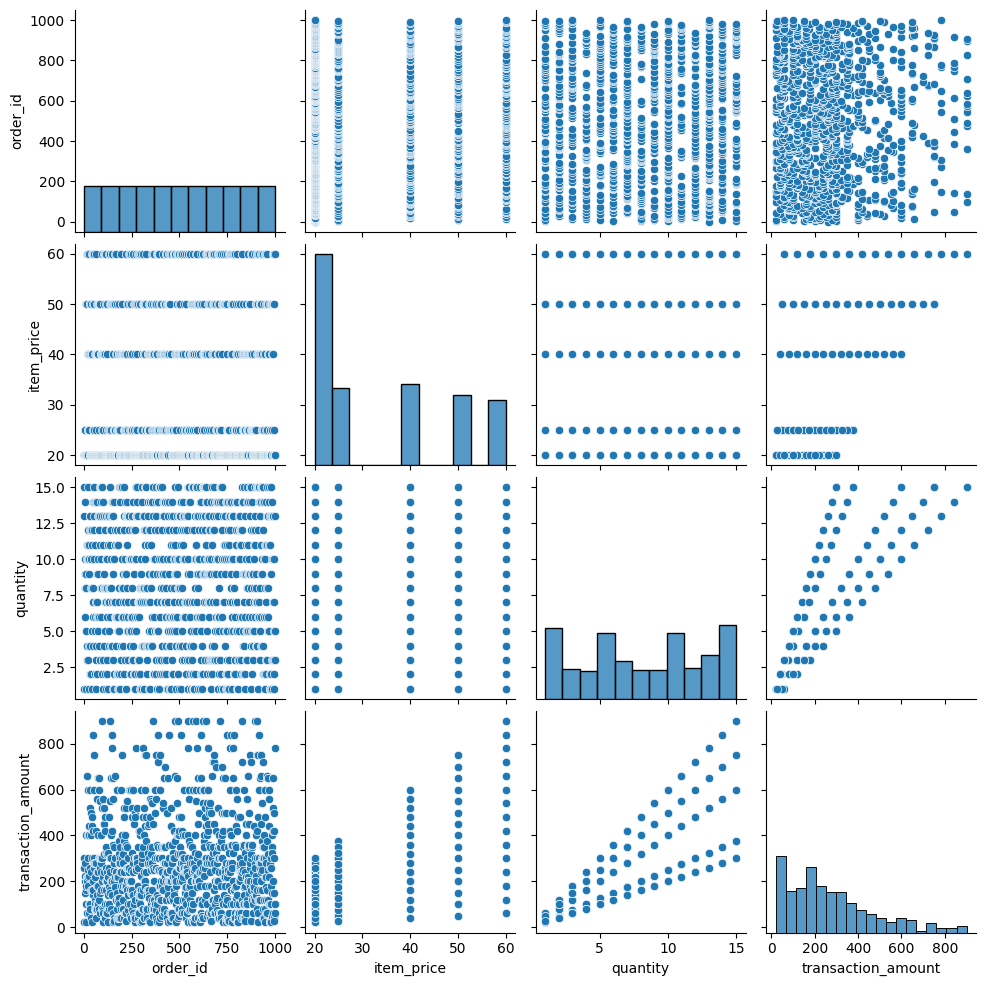

In [14]:
#Visualizamos un grafico para ver la relacion entre las variables
sns.pairplot(df_restaurant_new)
plt.show()

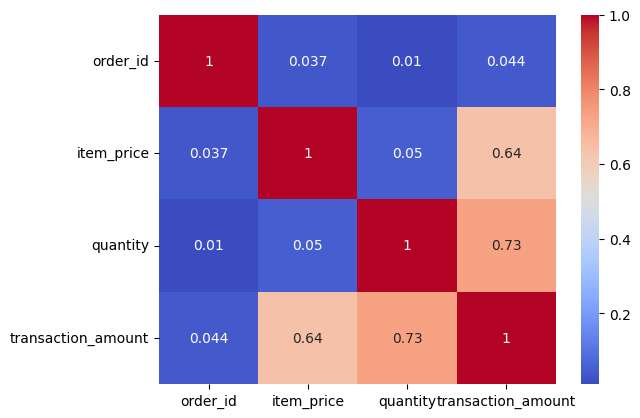

In [15]:
#Visualizamos un mapa de calor para ver la correlacion entre las variables
df_list = ["order_id","item_price","quantity","transaction_amount"]
sns.heatmap(df_restaurant_new[df_list].corr(), annot=True, cmap="coolwarm")
plt.show()

In [17]:
#Vemos las variables categoricas
#print(df_restaurant_new["date"].value_counts())
print(df_restaurant_new["item_name"].value_counts())
print(df_restaurant_new["item_type"].value_counts())
print(df_restaurant_new["transaction_type"].value_counts())
print(df_restaurant_new["received_by"].value_counts())
print(df_restaurant_new["time_of_sale"].value_counts())

item_name
Cold coffee        161
Sugarcane juice    153
Panipuri           150
Frankie            139
Aalopuri           134
Vadapav            134
Sandwich           129
Name: count, dtype: int64
item_type
Fastfood     686
Beverages    314
Name: count, dtype: int64
transaction_type
Cash       476
Online     417
Unknown    107
Name: count, dtype: int64
received_by
Mr.     512
Mrs.    488
Name: count, dtype: int64
time_of_sale
Night        205
Afternoon    205
Evening      201
Midnight     199
Morning      190
Name: count, dtype: int64


In [20]:
df_restaurant_new.drop(columns=["date"], inplace=True)

In [21]:
#Usamos OneHotEncoder para convertir las variables categoricas en variables numericas
#Y despues procesarlas para ver si son utiles
categorical_cols = ["item_name", "item_type", "transaction_type", "received_by", "time_of_sale"]
numerical_cols = [col for col in df_restaurant_new.columns if col not in categorical_cols]
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df_restaurant_new[categorical_cols])
column_transformer = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)],remainder='passthrough')
X_encoded = column_transformer.fit_transform(df_restaurant_new)
encoded_col_names = column_transformer.named_transformers_['cat'].get_feature_names_out(categorical_cols)
final_columns = list(encoded_col_names) + numerical_cols
df_encoded = pd.DataFrame(X_encoded, columns=final_columns)
print(df_encoded.head())


   item_name_Cold coffee  item_name_Frankie  item_name_Panipuri  \
0                    0.0                0.0                 0.0   
1                    0.0                0.0                 0.0   
2                    0.0                0.0                 0.0   
3                    0.0                0.0                 0.0   
4                    0.0                0.0                 0.0   

   item_name_Sandwich  item_name_Sugarcane juice  item_name_Vadapav  \
0                 0.0                        0.0                0.0   
1                 0.0                        0.0                1.0   
2                 0.0                        0.0                1.0   
3                 0.0                        1.0                0.0   
4                 0.0                        1.0                0.0   

   item_type_Fastfood  transaction_type_Online  transaction_type_Unknown  \
0                 1.0                      0.0                       1.0   
1                 

In [22]:
#Verificamos si nuestros datos siguen bien estructurados despues de la codificacion
df_encoded.describe()

,item_name_Cold coffee,item_name_Frankie,item_name_Panipuri,item_name_Sandwich,item_name_Sugarcane juice,item_name_Vadapav,item_type_Fastfood,transaction_type_Online,transaction_type_Unknown,received_by_Mrs.,time_of_sale_Evening,time_of_sale_Midnight,time_of_sale_Morning,time_of_sale_Night,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.161000,0.13900,0.15000,0.129000,0.153000,0.134000,0.686000,0.41700,0.107000,0.488000,0.201000,0.199000,0.190000,0.205000,500.500000,33.315000,8.162000,275.230000
std,0.367715,0.34612,0.35725,0.335368,0.360168,0.340823,0.464349,0.49331,0.309268,0.500106,0.400949,0.399448,0.392497,0.403904,288.819436,14.921744,4.413075,204.402979
min,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,20.000000,1.000000,20.000000
25%,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,250.750000,20.000000,4.000000,120.000000
50%,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500.500000,25.000000,8.000000,240.000000
75%,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,750.250000,50.000000,12.000000,360.000000
max,1.000000,1.00000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1000.000000,60.000000,15.000000,900.000000


<Axes: >

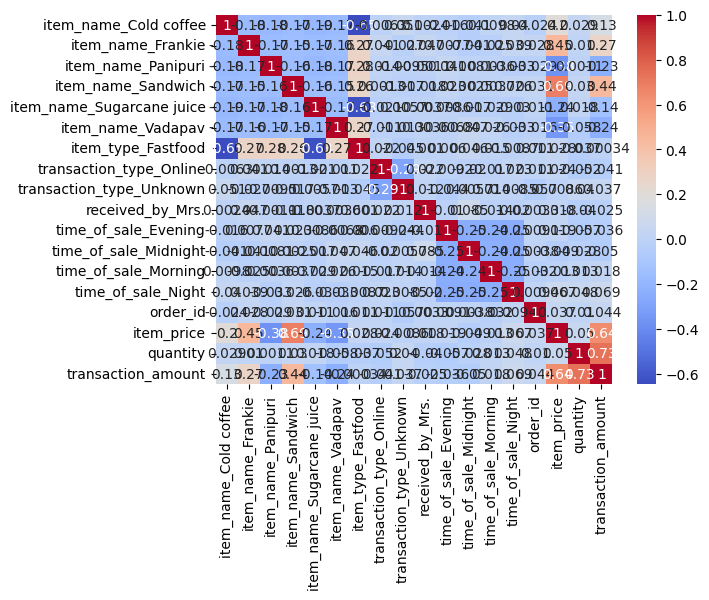

In [23]:
#Hacemos un grafico de calor para ver si realmente tienen alguna rlacion importante con la variable objetivo
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")

In [27]:
#Seleccionamos las variables que creemos que pueden tener una relacion importante con la variable objetivo y las separamos en X e y
var_cols = ["item_name_Cold coffee","item_name_Frankie","item_name_Panipuri","item_name_Sandwich","item_name_Sugarcane juice","item_name_Vadapav","item_type_Fastfood","transaction_type_Online","transaction_type_Unknown","received_by_Mrs.","time_of_sale_Evening","time_of_sale_Midnight","time_of_sale_Morning","time_of_sale_Night","order_id","item_price","quantity"]
X = df_encoded[var_cols]
y = df_encoded["transaction_amount"]

In [28]:
#Dividimos el dataset en un conjunto de entrenamiento y otro de prueba, entrenamos el modelo de regresion lineal y lo ajustamos a los datos de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
print('ß0: ', round(model.intercept_,3))
for i in range(0, len(model.coef_)):
    print('ß'+str(i+1)+': ', round(model.coef_[i],3), 'asociado a variable', model.feature_names_in_[i])

ß0:  -264.444
ß1:  0.805 asociado a variable item_name_Cold coffee
ß2:  -0.54 asociado a variable item_name_Frankie
ß3:  -7.749 asociado a variable item_name_Panipuri
ß4:  0.744 asociado a variable item_name_Sandwich
ß5:  -4.319 asociado a variable item_name_Sugarcane juice
ß6:  2.779 asociado a variable item_name_Vadapav
ß7:  3.513 asociado a variable item_type_Fastfood
ß8:  -3.158 asociado a variable transaction_type_Online
ß9:  14.211 asociado a variable transaction_type_Unknown
ß10:  -3.503 asociado a variable received_by_Mrs.
ß11:  -4.671 asociado a variable time_of_sale_Evening
ß12:  0.343 asociado a variable time_of_sale_Midnight
ß13:  4.982 asociado a variable time_of_sale_Morning
ß14:  -2.079 asociado a variable time_of_sale_Night
ß15:  0.015 asociado a variable order_id
ß16:  8.083 asociado a variable item_price
ß17:  32.337 asociado a variable quantity


In [30]:
list(zip(var_cols,model.coef_))

[('item_name_Cold coffee', np.float64(0.8053468260812965)),
 ('item_name_Frankie', np.float64(-0.5401667245051751)),
 ('item_name_Panipuri', np.float64(-7.748605394502721)),
 ('item_name_Sandwich', np.float64(0.7443631436519842)),
 ('item_name_Sugarcane juice', np.float64(-4.318676661314277)),
 ('item_name_Vadapav', np.float64(2.7793336676829705)),
 ('item_type_Fastfood', np.float64(3.51332983523302)),
 ('transaction_type_Online', np.float64(-3.157595613795953)),
 ('transaction_type_Unknown', np.float64(14.210695368616427)),
 ('received_by_Mrs.', np.float64(-3.503484883816038)),
 ('time_of_sale_Evening', np.float64(-4.670577955805239)),
 ('time_of_sale_Midnight', np.float64(0.34333447006426293)),
 ('time_of_sale_Morning', np.float64(4.982267498362867)),
 ('time_of_sale_Night', np.float64(-2.0791376719389842)),
 ('order_id', np.float64(0.01543588504586838)),
 ('item_price', np.float64(8.083077225977696)),
 ('quantity', np.float64(32.336619650830805))]

In [31]:
model.score(X_test, y_test)
#model.score(X_train, y_train)

0.9019352424778339

In [33]:
df_encoded['prediction'] = model.predict(X)

df_encoded.sample(15)

,item_name_Cold coffee,item_name_Frankie,item_name_Panipuri,item_name_Sandwich,item_name_Sugarcane juice,item_name_Vadapav,item_type_Fastfood,transaction_type_Online,transaction_type_Unknown,received_by_Mrs.,time_of_sale_Evening,time_of_sale_Midnight,time_of_sale_Morning,time_of_sale_Night,order_id,item_price,quantity,transaction_amount,prediction
181,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,182.0,40.0,1.0,40.0,95.173704
929,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,930.0,25.0,10.0,250.0,265.799073
883,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,884.0,20.0,12.0,240.0,299.958216
552,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,553.0,20.0,14.0,280.0,349.560393
51,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,52.0,25.0,12.0,300.0,318.996188
402,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,403.0,40.0,3.0,120.0,156.597193
529,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,530.0,20.0,6.0,120.0,89.600366
49,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,50.0,20.0,8.0,160.0,159.814792
117,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,118.0,60.0,1.0,60.0,256.142102
386,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,387.0,25.0,14.0,350.0,388.840449


In [35]:
### metricas
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print('mse: ', round(mse,2), 'transaction_amount^2')
print('rmse: ', round(np.sqrt(mse),2), 'transaction_amount')
r2 = r2_score(y_test, y_pred)
print('r2: ', round(r2,2))
mae = mean_absolute_error(y_test, y_pred)
print('mae: ', round(mae,2), 'transaction_amount')

mse:  4213.59 transaction_amount^2
rmse:  64.91 transaction_amount
r2:  0.9
mae:  51.9 transaction_amount


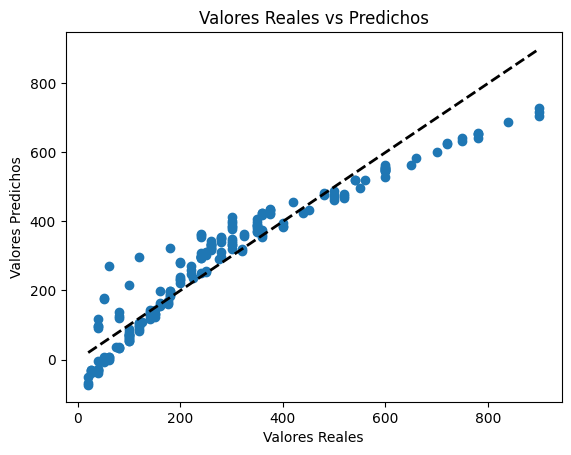

In [36]:
#Graficamos los valores reales con los predichos
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs Predichos')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()